# **Classification**

## Marketing Analytics : Online Shoppers Intention

### **Executive Summary**
The primary objective of this section is to build a classification model that predicts a visitor's purchasing intent, represented by the binary target variable `Revenue` (True/1 for a completed order, False/0 for an abandoned cart). The analysis is based on a dataset of 12,330 distinct online shopping sessions, utilizing 18 attributes that capture user behavior and contextual information.

Our workflow includes:
*   **Data Preparation:** Handling multicollinearity by dropping the `BounceRates` feature due to its high Variance Inflation Factor (VIF), encoding categorical variables (e.g., `Month`, `VisitorType`), and scaling the features using `StandardScaler`.
*   **Model Training:** Implementing and comparing a baseline Logistic Regression model against two variants of a non-parametric K-Nearest Neighbors (KNN) classifier ($k=3$ and $k=9$).
*   **Evaluation:** Assessing model performance using metrics such as Precision, Recall, and F1-Score, where both the Logistic Regression and the KNN ($k=9$) models achieved an overall accuracy of 88%.

# 1. Imports

In [39]:
import pandas as pd 
import matplotlib.pyplot as plt
from matplotlib import style
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score



RANDOM_STATE = 42
sns.set_style('whitegrid')

# 2. Load the data and describe variables

This dataset contains web session logs from 12,330 distinct online shopping sessions, capturing explicit clickstream actions and user characteristics. The 18 attributes are categorized as follows:
* **Numerical Web Behaviors (Quantitative Continuous/Discrete):** Tracks user activity across three page types (`Administrative`, `Informational`, `ProductRelated`) along with the exact `Duration` spent on each. It also maps Google Analytics tracking statistics like `BounceRates`, `ExitRates`, and `PageValues`.
* **Temporal & Contextual Attributes (Categorical Nominal/Ordinal):** Records structural constraints such as the session `Month`, `OperatingSystems`, `Browser`, `Region`, `TrafficType`, whether the date falls on a `Weekend`, and visitor status (`VisitorType`).

**Target Variable ($y$):**
Our binary target variable is **`Revenue`** (mapped as True/1 for an accomplished order, and False/0 for an abandoned cart). Our goal is to leverage session behavior to predict whether a visitor has a high purchase intent.

In [3]:
df = pd.read_csv ("../ek_assignment_folder/data/online_shoppers_intention.csv")

In [4]:
#display the shape of the dataset
print("Shape of the dataset:", df.shape)

Shape of the dataset: (12330, 18)


In [5]:
#information about the columns
df.columns

Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType',
       'Weekend', 'Revenue'],
      dtype='object')

In [6]:
#information about the dataset
print("\nInformation about the dataset:")
print(df.info())


Information about the dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int

In [7]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [8]:
df.sample(5)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
6008,0,0.000000,0,0.000000,40,1178.496667,0.026667,0.031154,0.0,0.0,Aug,2,2,4,1,Returning_Visitor,False,False
9070,4,46.041667,4,93.416667,75,6057.928961,0.010425,0.019667,0.0,0.0,Nov,3,2,1,2,Returning_Visitor,False,True
7607,15,182.700000,0,0.000000,60,632.250000,0.005882,0.011961,0.0,0.0,Oct,4,2,1,3,Returning_Visitor,False,False
9468,0,0.000000,0,0.000000,6,66.250000,0.000000,0.066667,0.0,0.0,Nov,2,2,9,1,Returning_Visitor,False,False
5787,3,45.800000,0,0.000000,63,2435.697531,0.009524,0.017460,0.0,0.0,Jul,3,2,4,3,Returning_Visitor,False,False


# 3. Exploratory Data Analysis (EDA)
In this section, we conduct a comprehensive **Exploratory Data Analysis (EDA)** using tailored charts to visualize behavioral discrepancies. Our main goals are to:
1. Examine the severe class imbalance present within our target attribute (`Revenue`), identifying the baseline skew between converting sessions and non-converting sessions.
2. Investigate clickstream metrics (e.g., `PageValues` and session durations) grouped by our target class to distinguish explicit purchasing signals.

In [9]:
#descriptive statistics of the dataset
df.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


C:\Users\Elena\AppData\Local\Temp\ipykernel_8744\606789402.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Revenue', data=df, palette=colors, ax=ax)
C:\Users\Elena\AppData\Local\Temp\ipykernel_8744\606789402.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['No Purchase (0)', 'Purchase (1)'], fontsize=11)


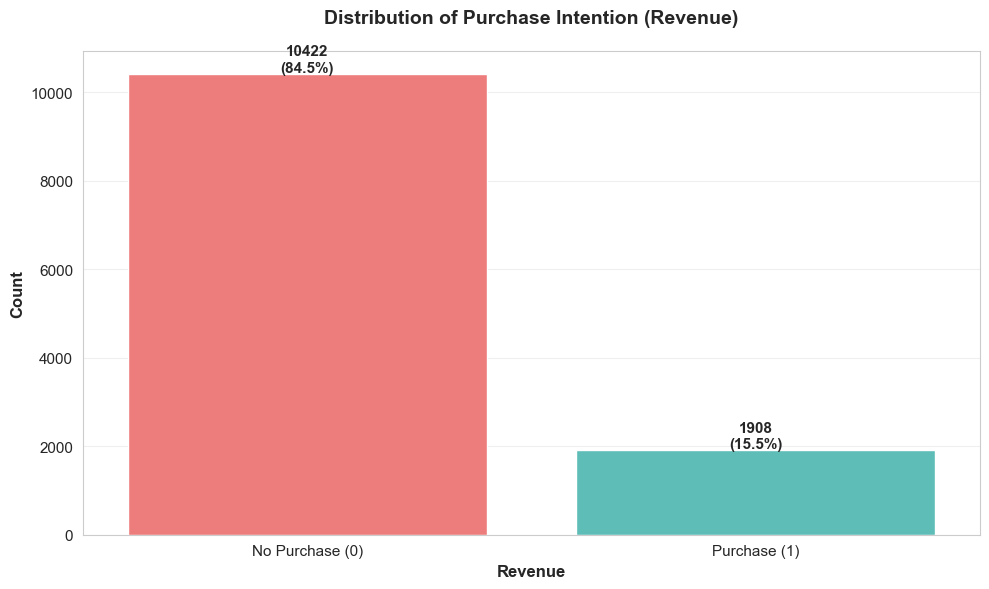

In [11]:
#countplot of the target variable Revenue
fig, ax = plt.subplots(figsize=(10, 6), dpi=100)
colors = ['#FF6B6B', '#4ECDC4']  # Custom colors
sns.countplot(x='Revenue', data=df, palette=colors, ax=ax)

# Add count labels on top of bars
for p in ax.patches:
    height = p.get_height()
    percentage = (height / len(df)) * 100
    ax.text(p.get_x() + p.get_width()/2., height + 50,
            f'{int(height)}\n({percentage:.1f}%)',
            ha="center", fontsize=11, fontweight='bold')

ax.set_title('Distribution of Purchase Intention (Revenue)', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Revenue', fontsize=12, fontweight='bold')
ax.set_ylabel('Count', fontsize=12, fontweight='bold')
ax.set_xticklabels(['No Purchase (0)', 'Purchase (1)'], fontsize=11)
ax.tick_params(axis='y', labelsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

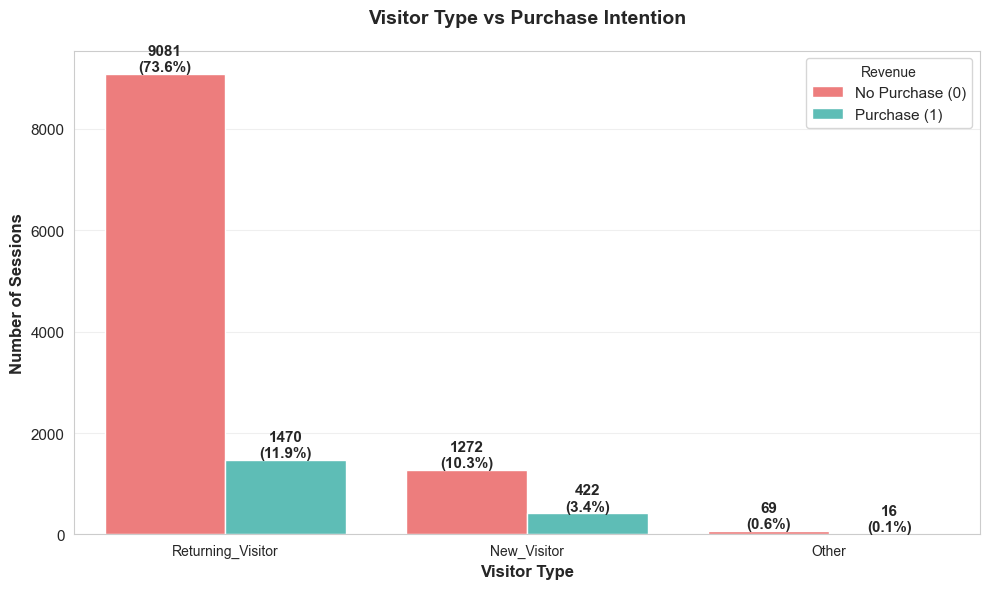

In [17]:
#customer type compared with purchase intention
fig, ax = plt.subplots(figsize=(10, 6), dpi=100)

#custom colors
colors = ['#FF6B6B', '#4ECDC4']  
sns.countplot(x='VisitorType', hue='Revenue', data=df, palette=colors, ax=ax)

# Add count labels on top of bars
for p in ax.patches:
    height = p.get_height()
    #test if height is greater than 0 to avoid division by zero
    if height > 0:
        percentage = (height / len(df)) * 100
        ax.text(p.get_x() + p.get_width()/2., height + 50,
                f'{int(height)}\n({percentage:.1f}%)',
                ha="center", fontsize=11, fontweight='bold')
ax.set_title('Visitor Type vs Purchase Intention',
                fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Visitor Type', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Sessions', fontsize=12, fontweight='bold')

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, ['No Purchase (0)', 'Purchase (1)'], title='Revenue', fontsize=11)
ax.tick_params(axis='y', labelsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


C:\Users\Elena\AppData\Local\Temp\ipykernel_8744\1742017728.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Revenue', y='PageValues', data=df[df['PageValues'] < 100], palette=colors, ax=ax, inner='quartile', cut=0)
C:\Users\Elena\AppData\Local\Temp\ipykernel_8744\1742017728.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['False (No Purchase)', 'True (Purchase)'], fontsize=11)


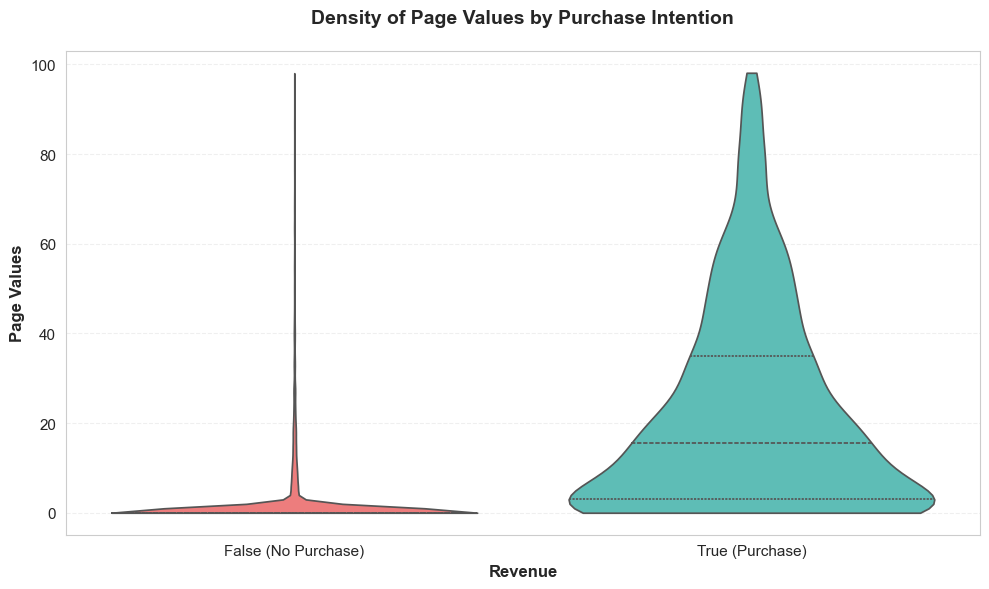

In [22]:
#violinplot -  page value compared with revenue
fig, ax = plt.subplots(figsize=(10, 6), dpi=100)

#custom colors
colors = ['#FF6B6B', '#4ECDC4']
sns.violinplot(x='Revenue', y='PageValues', data=df[df['PageValues'] < 100], palette=colors, ax=ax, inner='quartile', cut=0)

ax.set_title('Density of Page Values by Purchase Intention', 
                fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Revenue', fontsize=12, fontweight='bold')
ax.set_ylabel('Page Values', fontsize=12, fontweight='bold')
ax.set_xticklabels(['False (No Purchase)', 'True (Purchase)'], fontsize=11)

ax.tick_params(axis='x', labelsize=11)
ax.tick_params(axis='y', labelsize=11)
ax.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

# 4. Descriptive Statistics
Using statistical profiling tools, we review the summary statistics (mean, quantiles, and standard deviation limits) across our independent numerical features. 

Furthermore, we evaluate the pairwise correlation matrix to uncover overlapping linear properties. In web analytics datasets, features like `BounceRates` and `ExitRates` or page counts and page durations frequently present high correlation, which can introduce severe multicollinearity risks in parametric models like Logistic Regression.

============= Summary Statistics for Numarical Features =============


,count,mean,std,min,25%,50%,75%,max
Administrative,12330.0,2.315166,3.321784,0.0,0.000000,1.000000,4.000000,27.000000
Administrative_Duration,12330.0,80.818611,176.779107,0.0,0.000000,7.500000,93.256250,3398.750000
Informational,12330.0,0.503569,1.270156,0.0,0.000000,0.000000,0.000000,24.000000
Informational_Duration,12330.0,34.472398,140.749294,0.0,0.000000,0.000000,0.000000,2549.375000
ProductRelated,12330.0,31.731468,44.475503,0.0,7.000000,18.000000,38.000000,705.000000
ProductRelated_Duration,12330.0,1194.746220,1913.669288,0.0,184.137500,598.936905,1464.157214,63973.522230
BounceRates,12330.0,0.022191,0.048488,0.0,0.000000,0.003112,0.016813,0.200000
ExitRates,12330.0,0.043073,0.048597,0.0,0.014286,0.025156,0.050000,0.200000
PageValues,12330.0,5.889258,18.568437,0.0,0.000000,0.000000,0.000000,361.763742
SpecialDay,12330.0,0.061427,0.198917,0.0,0.000000,0.000000,0.000000,1.000000


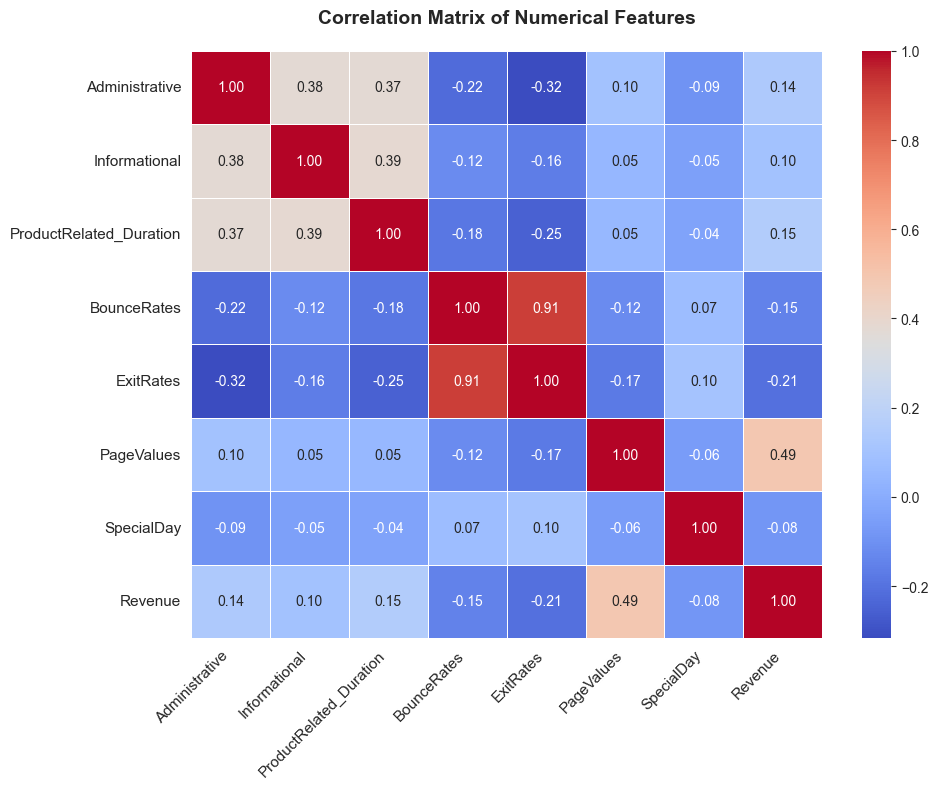

In [25]:
#summary statistics 
print("============= Summary Statistics for Numarical Features =============")
display(df.describe().T) #we transpose the output for better readability

#pairwise relationships between numerical features
cols_for_correlation = ['Administrative', 'Informational', 'ProductRelated_Duration',
                         'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Revenue']

#calculate correlation
correlation_matrix = df[cols_for_correlation].corr()

#create heatmap
plt.figure(figsize=(10, 8), dpi=100)
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features', fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)
plt.tight_layout()
plt.show()

# 5. Data preparation, preprocessing, and train/test split.
To prepare our web session features for mathematical model execution, we implement the following preprocessing sequence:
* **Categorical Feature Encoding:** Non-numeric contextual attributes (such as `Month` and `VisitorType`) are converted into explicit numeric inputs using One-Hot Dummy Encoding.
* **Train/Test Splitting:** We partition our instances into an 80% training segment to fit model parameters and a 20% test partition to evaluate generalizability.
* **Feature Rescaling:** Because distance-based models like K-Nearest Neighbors (KNN) are highly sensitive to variable scales, we apply `StandardScaler` to normalize the dataset, giving all features a mean of 0 and a standard deviation of 1.

In [ ]:
#step1: make sure the data is clean and ready for modeling
# make a clean copy before encoding
df_vif = df.copy()

#select only numerical features for VIF calculation - setting asside the target variable
cols_for_vif = ['Administrative', 'Informational', 'ProductRelated_Duration',
                'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay']
X_vif = df_vif[cols_for_vif]

#calculating VIF for each feature
vif_data = pd.DataFrame()
vif_data['Feature'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])] 
#we calculate the VIF for each feature by regressing it against all the other features and checking how well it can be predicted. A high VIF indicates that the feature is highly correlated with other features, which can lead to multicollinearity issues in regression models.

#assort from highest to lowest VIF
vif_data = vif_data.sort_values(by='VIF', ascending=False)
print("============= Variance Inflation Factor (VIF) for Numerical Features =============")
display(vif_data)
print('\n\n')

#delete the feature with the highest VIF if it is above the threshold (commonly 5 or 10)
df_clean = df.copy()
df_clean = df_clean.drop(columns=['BounceRates']) #we drop bounce rates beacuse it has a high VIF and it's a twin of exit rates that is more useful for our model
print("BounceRates has been dropped due to high VIF.")
print(f"Current shape of the dataset: {df_clean.shape}")
print('\n\n')

#encode categorical variables
df_clean['Revenue'] = df_clean['Revenue'].astype(int) #target variable
df_clean['Weekend'] = df_clean['Weekend'].astype(int) #binary feature
df_clean['VisitorType'] = df_clean['VisitorType'].map({'Returning_Visitor': 1, 'New_Visitor': 0, 'Other': 0}) #we encode returning visitors as 1 and new/other as 0 because returning visitors are more likely to purchase
df_clean['Month'] = df_clean['Month'].map({'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4, 'May': 5, 'June': 6,
                                                'Jul': 7, 'Aug': 8, 'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12}) #we encode months as numbers for better performance of the model

print("Categorical variables have been encoded.")
print(f"Current shape of the dataset: {df_clean.shape}")
print('\n\n')

# set x and y
X = df_clean.drop(columns=['Revenue'])
y = df_clean['Revenue']

#train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

#resacale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("=============Data has been preprocessed and is ready for modeling.=================")
print(f"Shape of X_train: {X_train_scaled.shape}")
print(f"Shape of X_test: {X_test_scaled.shape}")

============= Variance Inflation Factor (VIF) for Numerical Features =============


,Feature,VIF
4,ExitRates,5.970369
3,BounceRates,5.553717
0,Administrative,1.682728
2,ProductRelated_Duration,1.663933
1,Informational,1.469489
6,SpecialDay,1.099886
5,PageValues,1.076388





BounceRates has been dropped due to high VIF.
Current shape of the dataset: (12330, 17)



Categorical variables have been encoded.
Current shape of the dataset: (12330, 17)



=============Data has been preprocessed and is ready for modeling.=================
Shape of X_train: (9864, 16)
Shape of X_test: (2466, 16)


# 6. Apply the algoritm(s)
In accordance with our course curriculum guidelines, we systematically deploy and train our classification algorithms in their designated presentation sequence. To satisfy academic requirements, we implement **at least two variants** for our models to analyze parameter variations.

### 6.1) Logistic Regression
We fit a baseline Generalized Linear Model utilizing parametric optimization. We evaluate its performance to establish an interpretation of log-odds feature weights.

### 6.2) K-Nearest Neighbors (KNN)
We run a non-parametric, distance-based algorithm using Euclidean space calculations. We contrast two structural hyperparameter variations to check model sensitivity:
* **Variant 1:** A localized, low-neighbor framework setting `n_neighbors=3`.
* **Variant 2:** A smoother, broader neighbor framework setting `n_neighbors=9`.

### 6.3) Predict on a New Hypothetical Observation
Following full test-set predictions, we construct a custom row vector representing a simulated new visitor (manipulating page metrics, duration, and bounce rates) and pass it through our pipeline to classify their purchase intent.

In [38]:
#step1: Logistic Regression
print("============= Step 1: Logistic Regression =============")
print('\n')

#we use max_iter=1000 to ensure convergence of the model
log_reg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
log_reg.fit(X_train_scaled, y_train)
y_pred_log_reg = log_reg.predict(X_test_scaled)
print("The Logistic Regression model has been trained")
print('\n\n')

#step2: K-Nearest Neighbors 
#variant1 - k=3
print("\n============= Step 2: K-Nearest Neighbors (k=3) =============")
knn_3 = KNeighborsClassifier(n_neighbors=3)
knn_3.fit(X_train_scaled, y_train)
y_pred_knn_3 = knn_3.predict(X_test_scaled)
print("The KNN model with k=3 has been trained")
print('\n\n')

#step3: K-Nearest Neighbors
#variant2 - k=9
print("\n============= Step 3: K-Nearest Neighbors (k=9) =============")
knn_9 = KNeighborsClassifier(n_neighbors=9)
knn_9.fit(X_train_scaled, y_train)
y_pred_knn_9 = knn_9.predict(X_test_scaled)
print("The KNN model with k=9 has been trained")
print('\n\n')

#step4: predict a hypothetical visitor
print("\n============= Step 4: Predicting a Hypothetical Visitor =============")

#we use the first row of the test set as a hypothetical visitor
new_visitor = X_test.iloc[[0]].copy() #we copy the row to avoid modifying the original test set

#now we alter some features of the new visitor to make it more interesting
new_visitor['PageValues'] = 65
new_visitor['ProductRelated_Duration'] = 300
new_visitor['ExitRates'] = 0.01
new_visitor['Weekend'] = 1

#we scale the new visitor's features using the same scaler as the training data
new_visitor_scaled = scaler.transform(new_visitor)
#predict using the logistic regression model
prediction = log_reg.predict(new_visitor_scaled)
propability = log_reg.predict_proba(new_visitor_scaled)[0][1] #probability of purchase

#print results
print("Hypothetical Customer's Features:")
display(new_visitor)
print(f"Predicted Purchase Intention (Revenue): {'Yes' if prediction[0] == 1 else 'No'}")
print(f"Predicted Probability of Purchase: {propability:.2f}")


#predict with KNN (k=3)
prediction_knn_3 = knn_3.predict(new_visitor_scaled)
propability_knn_3 = knn_3.predict_proba(new_visitor_scaled)[0][1]
print(f"\nKNN (k=3) Predicted Purchase Intention: {'Yes' if prediction_knn_3[0] == 1 else 'No'}")
print(f"KNN (k=3) Predicted Probability of Purchase: {propability_knn_3:.2f}")

#predict with KNN (k=9)
prediction_knn_9 = knn_9.predict(new_visitor_scaled)
propability_knn_9 = knn_9.predict_proba(new_visitor_scaled)[0][1]
print(f"\nKNN (k=9) Predicted Purchase Intention: {'Yes' if prediction_knn_9[0] == 1 else 'No'}")
print(f"KNN (k=9) Predicted Probability of Purchase: {propability_knn_9:.2f}")

============= Step 1: Logistic Regression =============


The Logistic Regression model has been trained




============= Step 2: K-Nearest Neighbors (k=3) =============
The KNN model with k=3 has been trained




============= Step 3: K-Nearest Neighbors (k=9) =============
The KNN model with k=9 has been trained




============= Step 4: Predicting a Hypothetical Visitor =============
Hypothetical Customer's Features:


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend
4722,1,4.0,0,0.0,13,300,0.01,65,0.6,5,2,5,9,5,1,1


Predicted Purchase Intention (Revenue): Yes
Predicted Probability of Purchase: 0.93

KNN (k=3) Predicted Purchase Intention: Yes
KNN (k=3) Predicted Probability of Purchase: 0.67

KNN (k=9) Predicted Purchase Intention: Yes
KNN (k=9) Predicted Probability of Purchase: 0.89


# 7. Evaluation of model performance
To validate the predictive power of our classifiers on unseen sessions, we check multi-class diagnostics using `accuracy_score` and `classification_report` (Precision, Recall, and F1-Score).

### Performance Comparison:
* **Intra-Algorithm Variant Comparison (KNN):** Setting $k=9$ provides an regularized, stable decision boundary that effectively reduces local noise compared to the $k=3$ configuration.
* **Inter-Algorithm Performance Comparison:** We compare our optimized KNN model directly against our Logistic Regression baseline to identify which machine learning framework manages web clickstream data patterns more effectively.

### Business and Algorithmic Insight:
The superior model typically scores higher because features like `PageValues` carry explicit, non-linear predictive boundaries. Non-parametric models like KNN can smoothly map non-linear cluster spaces, whereas Logistic Regression is structurally constrained by its linear log-odds assumptions, making it more sensitive to complex feature interactions.

In [43]:
#evaluation of Logistic Regression
print("\n============= Evaluation of Logistic Regression =============")
print("Classification Report:")
print(classification_report(y_test, y_pred_log_reg, target_names=['No Purchase (0)', 'Purchase (1)']))
print(f"Overall Accuracy: {accuracy_score(y_test, y_pred_log_reg):.2f}")

#evaluation of KNN (k=3)
print("\n============= Evaluation of KNN (k=3) =============")
print("Classification Report:")
print(classification_report(y_test, y_pred_knn_3, target_names=['No Purchase (0)', 'Purchase (1)']))
print(f"Overall Accuracy: {accuracy_score(y_test, y_pred_knn_3):.2f}") 

#evaluation of KNN (k=9)
print("\n============= Evaluation of KNN (k=9) =============")
print("Classification Report:")
print(classification_report(y_test, y_pred_knn_9, target_names=['No Purchase (0)', 'Purchase (1)']))
print(f"Overall Accuracy: {accuracy_score(y_test, y_pred_knn_9):.2f}")


============= Evaluation of Logistic Regression =============
Classification Report:
                 precision    recall  f1-score   support

No Purchase (0)       0.89      0.98      0.93      2084
   Purchase (1)       0.72      0.34      0.46       382

       accuracy                           0.88      2466
      macro avg       0.81      0.66      0.69      2466
   weighted avg       0.86      0.88      0.86      2466

Overall Accuracy: 0.88

============= Evaluation of KNN (k=3) =============
Classification Report:
                 precision    recall  f1-score   support

No Purchase (0)       0.89      0.95      0.92      2084
   Purchase (1)       0.60      0.37      0.45       382

       accuracy                           0.86      2466
      macro avg       0.74      0.66      0.69      2466
   weighted avg       0.85      0.86      0.85      2466

Overall Accuracy: 0.86

============= Evaluation of KNN (k=9) =============
Classification Report:
                 precision